In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import glob
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import os
import pandas as pd

In [2]:
years = [2008, 2009, 2010, 2011, 2012]

output_dir = "/ocean/dtaneja/MOAD/analysis-dishika/notebooks/data"
os.makedirs(output_dir, exist_ok=True)

In [3]:
# # Run only once
# for year in years:
#     print("Processing HRDPS data for",year)
#     hrdps_files = sorted(glob.glob(f"/results/forcing/atmospheric/GEM2.5/gemlam/"f"gemlam_y{year}m??d??.nc"))
    
#     combined = []
    
#     for file in hrdps_files:
#         with xr.open_dataset(file) as ds:
#             solar_data = ds["solar"]
#             solar_data = solar_data.sortby("time_counter")
#             time_index = solar_data.get_index("time_counter")
#             if time_index.has_duplicates:
#                 unique_mask = ~time_index.duplicated()
#                 solar_data = solar_data.isel(time_counter=unique_mask)
#             solar_3h = (solar_data.resample(time_counter="3h",label="left",closed="left",origin="start_day").mean().load())
#             combined.append(solar_3h)
    
#     ds_hrdps_year = xr.concat(combined, dim="time_counter")
#     ds_hrdps_year = ds_hrdps_year.sortby("time_counter")
#     time_index = ds_hrdps_year.get_index("time_counter")
#     if time_index.has_duplicates:
#         unique_mask = ~time_index.duplicated()
#         ds_hrdps_year = ds_hrdps_year.isel(time_counter=unique_mask)
    
#     with xr.open_dataset(hrdps_files[0]) as ds0:
#         lat_hr = ds0["nav_lat"].load()
#         lon_hr = ds0["nav_lon"].load()

#     ds_hrdps_year = (ds_hrdps_year.to_dataset(name="solar").assign_coords(nav_lat=lat_hr,nav_lon=lon_hr))
#     output_file = f"{output_dir}/HRDPS_{year}_solar_3h_with_latlon.nc"
#     ds_hrdps_year.to_netcdf(output_file)
    
#     print("Saved:", output_file)
#     print(
#         "Time range:",
#         ds_hrdps_year.time_counter.values[0],
#         "to",
#         ds_hrdps_year.time_counter.values[-1]
#     )

In [4]:
hrdps_processed_files = []
for year in years:
    file = f"{output_dir}/HRDPS_{year}_solar_3h_with_latlon.nc"
    hrdps_processed_files.append(file)
ds_hrdps = xr.open_mfdataset(hrdps_processed_files,combine="by_coords")
ds_hrdps = ds_hrdps.sortby("time_counter")
print(ds_hrdps)

/tmp/ipykernel_3274135/2358249547.py:5: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  ds_hrdps = xr.open_mfdataset(hrdps_processed_files,combine="by_coords")


<xarray.Dataset> Size: 12GB
Dimensions:       (time_counter: 14592, y: 266, x: 256)
Coordinates:
  * time_counter  (time_counter) datetime64[ns] 117kB 2008-01-01 ... 2012-12-...
    nav_lat       (time_counter, y, x) float32 4GB 45.61 45.62 ... 52.37 52.37
    nav_lon       (time_counter, y, x) float32 4GB 232.7 232.7 ... 239.6 239.7
Dimensions without coordinates: y, x
Data variables:
    solar         (time_counter, y, x) float32 4GB dask.array<chunksize=(2912, 266, 256), meta=np.ndarray>


In [5]:
print("First timestamp:", ds_hrdps.time_counter.values[0])
print("Last timestamp: ", ds_hrdps.time_counter.values[-1])

First timestamp: 2008-01-01T00:00:00.000000000
Last timestamp:  2012-12-31T21:00:00.000000000


In [6]:
# Training: 2009, 2010, and 2011
ds_hrdps_train = ds_hrdps.sel(time_counter=slice("2009-01-01", "2011-12-31"))
# Validation: 2008
ds_hrdps_val = ds_hrdps.sel(time_counter=slice("2008-01-01", "2008-12-31"))
# Testing: 2012
ds_hrdps_test = ds_hrdps.sel(time_counter=slice("2012-01-01", "2012-12-31"))
print("HRDPS Training:")
print(ds_hrdps_train.time_counter.values[0],"to",ds_hrdps_train.time_counter.values[-1])
print("HRDPS Validation:")
print(ds_hrdps_val.time_counter.values[0],"to",ds_hrdps_val.time_counter.values[-1])
print("HRDPS Testing:")
print(ds_hrdps_test.time_counter.values[0],"to",ds_hrdps_test.time_counter.values[-1])

HRDPS Training:
2009-01-01T00:00:00.000000000 to 2011-12-31T21:00:00.000000000
HRDPS Validation:
2008-01-01T00:00:00.000000000 to 2008-12-31T21:00:00.000000000
HRDPS Testing:
2012-01-01T00:00:00.000000000 to 2012-12-31T21:00:00.000000000


In [7]:
canrcm_files = sorted(glob.glob("/results/forcing/CanRCM5/*.nc"))
canrcm_years = [2008, 2009, 2010, 2011, 2012]
canrcm_tas_files = []
for year in canrcm_years:
    matches = sorted(glob.glob(f"/results/forcing/CanRCM5/"f"*_{year}01_{year}12_3h_rsds.nc"))
    canrcm_tas_files.append(matches[0])

print("CanRCM solar files:")
for file in canrcm_tas_files:
    print(file)

CanRCM solar files:
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_200801_200812_3h_rsds.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_200901_200912_3h_rsds.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_201001_201012_3h_rsds.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_201101_201112_3h_rsds.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_201201_201212_3h_rsds.nc


In [8]:
from datetime import timedelta
ds_canrcm = xr.open_mfdataset(canrcm_tas_files,combine="by_coords")
ds_canrcm = ds_canrcm.sortby("time")
ds_canrcm = ds_canrcm.assign_coords(time=ds_canrcm.time.values - timedelta(hours=3))
print(ds_canrcm)

<xarray.Dataset> Size: 7GB
Dimensions:       (time: 14600, bnds: 2, rlat: 320, rlon: 360)
Coordinates:
  * time          (time) object 117kB 2008-01-01 00:00:00 ... 2012-12-31 21:0...
  * rlat          (rlat) float64 3kB -35.11 -34.89 -34.67 ... 34.63 34.85 35.07
  * rlon          (rlon) float64 3kB -39.27 -39.05 -38.83 ... 39.27 39.49 39.71
    lon           (rlat, rlon) float64 922kB dask.array<chunksize=(320, 360), meta=np.ndarray>
    lat           (rlat, rlon) float64 922kB dask.array<chunksize=(320, 360), meta=np.ndarray>
Dimensions without coordinates: bnds
Data variables:
    time_bnds     (time, bnds) object 234kB dask.array<chunksize=(2920, 2), meta=np.ndarray>
    rotated_pole  (time) |S1 15kB b'' b'' b'' b'' b'' ... b'' b'' b'' b'' b''
    rsds          (time, rlat, rlon) float32 7GB dask.array<chunksize=(2920, 320, 360), meta=np.ndarray>
Attributes: (12/17)
    title:                          CanRCM4 model output prepared for CORDEX ...
    institution:                    

/tmp/ipykernel_3274135/3930337657.py:2: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds_canrcm = xr.open_mfdataset(canrcm_tas_files,combine="by_coords")


In [9]:
print("First timestamp:",ds_canrcm.time.values[0])
print("Last timestamp:",ds_canrcm.time.values[-1])

First timestamp: 2008-01-01 00:00:00
Last timestamp: 2012-12-31 21:00:00


In [10]:
lat_hr = ds_hrdps["nav_lat"]
lon_hr = ds_hrdps["nav_lon"]
lon_hr_normalized = ((lon_hr + 180) % 360) - 180
lat_min = float(lat_hr.min())
lat_max = float(lat_hr.max())
lon_min = float(lon_hr_normalized.min())
lon_max = float(lon_hr_normalized.max())
print("HRDPS latitude range:")
print(lat_min, "to", lat_max)
print("HRDPS longitude range:")
print(lon_min, "to", lon_max)
lat_lr = ds_canrcm["lat"]
lon_lr = ds_canrcm["lon"]
lon_lr_normalized = ((lon_lr + 180) % 360) - 180
mask_lr = ((lat_lr >= lat_min) &(lat_lr <= lat_max) &(lon_lr_normalized >= lon_min) &(lon_lr_normalized <= lon_max))
i_idx, j_idx = np.where(mask_lr.values)
i_min = i_idx.min()
i_max = i_idx.max()
j_min = j_idx.min()
j_max = j_idx.max()
print("CanRCM grid indices:")
print("rlat:", i_min, "to", i_max)
print("rlon:", j_min, "to", j_max)

HRDPS latitude range:
45.52116012573242 to 52.4603157043457
HRDPS longitude range:
-129.47222900390625 to -119.20327758789062
CanRCM grid indices:
rlat: 161 to 200
rlon: 79 to 117


In [11]:
ds_canrcm_cut = (ds_canrcm[["rsds"]].isel(rlat=slice(i_min, i_max + 1),rlon=slice(j_min, j_max + 1)))
print(ds_canrcm_cut)

<xarray.Dataset> Size: 91MB
Dimensions:  (time: 14600, rlat: 40, rlon: 39)
Coordinates:
  * time     (time) object 117kB 2008-01-01 00:00:00 ... 2012-12-31 21:00:00
  * rlat     (rlat) float64 320B 0.31 0.53 0.75 0.97 ... 8.23 8.45 8.67 8.89
  * rlon     (rlon) float64 312B -21.89 -21.67 -21.45 ... -13.97 -13.75 -13.53
    lon      (rlat, rlon) float64 12kB dask.array<chunksize=(40, 39), meta=np.ndarray>
    lat      (rlat, rlon) float64 12kB dask.array<chunksize=(40, 39), meta=np.ndarray>
Data variables:
    rsds     (time, rlat, rlon) float32 91MB dask.array<chunksize=(2920, 40, 39), meta=np.ndarray>
Attributes: (12/17)
    title:                          CanRCM4 model output prepared for CORDEX ...
    institution:                    CCCma (Canadian Centre for Climate Modell...
    institute_id:                   CCCma
    driving_experiment:             , , r1i1p1
    driving_model_ensemble_member:  r1i1p1
    realization:                    1
    ...                             ..

In [12]:
# Training: 2009, 2010, and 2011
ds_canrcm_train = ds_canrcm_cut.sel(time=slice("2009-01-01", "2011-12-31"))
# Validation: 2008
ds_canrcm_val = ds_canrcm_cut.sel(time=slice("2008-01-01", "2008-12-31"))
# Testing: 2012
ds_canrcm_test = ds_canrcm_cut.sel(time=slice("2012-01-01", "2012-12-31"))
print("CanRCM Training:")
print(ds_canrcm_train.time.values[0], "to", ds_canrcm_train.time.values[-1])
print("CanRCM Validation:")
print(ds_canrcm_val.time.values[0], "to", ds_canrcm_val.time.values[-1])
print("CanRCM Testing:")
print(ds_canrcm_test.time.values[0], "to", ds_canrcm_test.time.values[-1])

CanRCM Training:
2009-01-01 00:00:00 to 2011-12-31 21:00:00
CanRCM Validation:
2008-01-01 00:00:00 to 2008-12-31 21:00:00
CanRCM Testing:
2012-01-01 00:00:00 to 2012-12-31 21:00:00


In [13]:
def time_to_string(value):
    if isinstance(value, np.datetime64):
        return np.datetime_as_string(value,unit="s").replace("T", " ")
    if hasattr(value, "strftime"):
        return value.strftime("%Y-%m-%d %H:%M:%S")
    raise TypeError(f"Unsupported time type: {type(value)}")

def align_time_pair(ds_canrcm_split, ds_hrdps_split):
    canrcm_times = []
    for t in ds_canrcm_split.time.values:
        canrcm_times.append(time_to_string(t))
    canrcm_times = np.array(canrcm_times)
    
    hrdps_times = []
    for t in ds_hrdps_split.time_counter.values:
        hrdps_times.append(time_to_string(t))
    hrdps_times = np.array(hrdps_times)
    
    common_times, canrcm_idx, hrdps_idx = np.intersect1d(canrcm_times,hrdps_times,return_indices=True)
    ds_canrcm_aligned = ds_canrcm_split.isel(time=canrcm_idx)
    ds_hrdps_aligned = ds_hrdps_split.isel(time_counter=hrdps_idx)
    
    return ds_canrcm_aligned, ds_hrdps_aligned

In [14]:
ds_canrcm_train, ds_hrdps_train = align_time_pair(ds_canrcm_train,ds_hrdps_train)
ds_canrcm_val, ds_hrdps_val = align_time_pair(ds_canrcm_val,ds_hrdps_val)
ds_canrcm_test, ds_hrdps_test = align_time_pair(ds_canrcm_test,ds_hrdps_test)
print("Training:")
print("CanRCM:", len(ds_canrcm_train.time))
print("HRDPS: ", len(ds_hrdps_train.time_counter))
print("Validation:")
print("CanRCM:", len(ds_canrcm_val.time))
print("HRDPS: ", len(ds_hrdps_val.time_counter))
print("Testing:")
print("CanRCM:", len(ds_canrcm_test.time))
print("HRDPS: ", len(ds_hrdps_test.time_counter))

Training:
CanRCM: 8760
HRDPS:  8760
Validation:
CanRCM: 2904
HRDPS:  2904
Testing:
CanRCM: 2912
HRDPS:  2912


In [15]:
mesh_mask_file = "/ocean/dtaneja/MOAD/analysis-dishika/grid/mesh_mask202108.nc"
weights_file = "/home/sallen/MEOPAR/grid/weights-gem2.5-gemlam_201702_pre22sep11.nc"
ds_mask = xr.open_dataset(mesh_mask_file)
ds_weights = xr.open_dataset(weights_file)
print(ds_weights)
print(ds_mask)

<xarray.Dataset> Size: 24MB
Dimensions:  (lat: 266, lon: 256, y: 898, x: 398)
Dimensions without coordinates: lat, lon, y, x
Data variables:
    nav_lat  (lat, lon) float64 545kB ...
    nav_lon  (lat, lon) float64 545kB ...
    src01    (y, x) int64 3MB ...
    wgt01    (y, x) float64 3MB ...
    src02    (y, x) int64 3MB ...
    wgt02    (y, x) float64 3MB ...
    src03    (y, x) int64 3MB ...
    wgt03    (y, x) float64 3MB ...
    src04    (y, x) int64 3MB ...
    wgt04    (y, x) float64 3MB ...
Attributes:
    Conventions:  CF-1.6
    title:        SalishSeaCast NEMO GEMLAM 2.5km Experimental pre-22-Sep-201...
    institution:  Dept of Earth, Ocean & Atmospheric Sciences, University of ...
    source:       NEMO_EastCoast/NEMO_Preparation/4_weights_ATMOS/get_weight_...
    references:   https://salishsea-meopar-docs.readthedocs.io/en/latest/code...
    history:      [2022-03-21 12:04:51] Converted to netCDF4 zlib=True datase...
    comment:      
<xarray.Dataset> Size: 788MB
Dimen

In [16]:
tmask2d = ds_mask["tmask"].isel(t=0, z=0)
water_mask = tmask2d.values.astype(bool)
ny, nx = water_mask.shape
print("SalishSeaCast shape:", ny, nx)
print("Number of water cells:", water_mask.sum())

SalishSeaCast shape: 898 398
Number of water cells: 81383


In [17]:
def make_hrdps_used_mask_from_ssc_water(da_hrdps, ds_weights, water_mask):
    da_hrdps = da_hrdps.squeeze(drop=True)
    time_dim = da_hrdps.dims[0]
    spatial_dims = da_hrdps.dims[1:]
    hrdps_shape = tuple(da_hrdps.sizes[d] for d in spatial_dims)
    n_hrdps_cells = np.prod(hrdps_shape)
    water_flat = water_mask.reshape(-1)
    water_indices = np.where(water_flat)[0]
    mask_hrdps_flat = np.zeros(n_hrdps_cells, dtype=bool)

    for n in range(1, 5):
        src_name = f"src{n:02d}"
        src_raw = ds_weights[src_name].values.reshape(-1)[water_indices].astype(np.int64)
        valid_src = src_raw > 0
        src = src_raw[valid_src] - 1
        if src.max() >= n_hrdps_cells:
            raise ValueError(
                f"{src_name} has source index {src.max()}, but HRDPS only has "
                f"{n_hrdps_cells} cells. Check grid shape/order."
            )
        mask_hrdps_flat[src] = True
    mask_hrdps_2d = mask_hrdps_flat.reshape(hrdps_shape)
    return mask_hrdps_2d, mask_hrdps_flat

In [18]:
mask_HRDPS_2d, mask_HRDPS_flat = make_hrdps_used_mask_from_ssc_water(
    ds_hrdps_train["solar"],
    ds_weights,
    water_mask
)

print("HRDPS mask shape:", mask_HRDPS_2d.shape)
print("Number of HRDPS cells used by SSC water cells:", mask_HRDPS_2d.sum())
print("Total HRDPS cells:", mask_HRDPS_2d.size)

HRDPS mask shape: (266, 256)
Number of HRDPS cells used by SSC water cells: 4731
Total HRDPS cells: 68096


In [19]:
def make_hrdps_matrix_from_used_mask(da_hrdps, mask_HRDPS_flat):
    da_hrdps = da_hrdps.squeeze(drop=True)
    time_dim = da_hrdps.dims[0]
    n_time = da_hrdps.sizes[time_dim]
    hrdps_flat = da_hrdps.values.reshape(n_time, -1).astype(np.float32)
    X = hrdps_flat[:, mask_HRDPS_flat]
    return X

In [20]:
X_hrdps_train_raw = make_hrdps_matrix_from_used_mask(ds_hrdps_train["solar"],mask_HRDPS_flat)
X_hrdps_val_raw = make_hrdps_matrix_from_used_mask(ds_hrdps_val["solar"],mask_HRDPS_flat)
X_hrdps_test_raw = make_hrdps_matrix_from_used_mask(ds_hrdps_test["solar"],mask_HRDPS_flat)
print("Raw HRDPS train matrix:", X_hrdps_train_raw.shape)
print("Raw HRDPS val matrix:  ", X_hrdps_val_raw.shape)
print("Raw HRDPS test matrix: ", X_hrdps_test_raw.shape)

Raw HRDPS train matrix: (8760, 4731)
Raw HRDPS val matrix:   (2904, 4731)
Raw HRDPS test matrix:  (2912, 4731)


In [21]:
def make_canrcm_matrix(da_canrcm):
    da_canrcm = da_canrcm.squeeze(drop=True)
    time_dim = da_canrcm.dims[0]
    n_time = da_canrcm.sizes[time_dim]
    X = da_canrcm.values.reshape(n_time, -1).astype(np.float32)
    return X

In [22]:
X_canrcm_train_raw = make_canrcm_matrix(ds_canrcm_train["rsds"])
X_canrcm_val_raw = make_canrcm_matrix(ds_canrcm_val["rsds"])
X_canrcm_test_raw = make_canrcm_matrix(ds_canrcm_test["rsds"])
print("Raw CanRCM train matrix:", X_canrcm_train_raw.shape)
print("Raw CanRCM val matrix:  ", X_canrcm_val_raw.shape)
print("Raw CanRCM test matrix: ", X_canrcm_test_raw.shape)

Raw CanRCM train matrix: (8760, 1560)
Raw CanRCM val matrix:   (2904, 1560)
Raw CanRCM test matrix:  (2912, 1560)


In [23]:
# Keep HRDPS cells that are valid for most training timestamps
valid_fraction = np.isfinite(X_hrdps_train_raw).mean(axis=0)
valid_hrdps_cols = valid_fraction > 0.95

X_hrdps_train = X_hrdps_train_raw[:, valid_hrdps_cols]
X_hrdps_val = X_hrdps_val_raw[:, valid_hrdps_cols]
X_hrdps_test = X_hrdps_test_raw[:, valid_hrdps_cols]

# Fill remaining NaNs using training column mean
hrdps_col_mean = np.nanmean(X_hrdps_train, axis=0)

inds = np.where(~np.isfinite(X_hrdps_train))
X_hrdps_train[inds] = np.take(hrdps_col_mean, inds[1])

inds = np.where(~np.isfinite(X_hrdps_val))
X_hrdps_val[inds] = np.take(hrdps_col_mean, inds[1])

inds = np.where(~np.isfinite(X_hrdps_test))
X_hrdps_test[inds] = np.take(hrdps_col_mean, inds[1])

# Update HRDPS mask for plotting
used_hrdps_indices = np.where(mask_HRDPS_flat)[0]
valid_used_hrdps_indices = used_hrdps_indices[valid_hrdps_cols]

mask_HRDPS_flat_valid = np.zeros_like(mask_HRDPS_flat, dtype=bool)
mask_HRDPS_flat_valid[valid_used_hrdps_indices] = True

mask_HRDPS_2d_valid = mask_HRDPS_flat_valid.reshape(mask_HRDPS_2d.shape)

print("Final number of valid HRDPS target cells:", mask_HRDPS_flat_valid.sum())
print("Final HRDPS train matrix:", X_hrdps_train.shape)
print("Final HRDPS val matrix:  ", X_hrdps_val.shape)
print("Final HRDPS test matrix: ", X_hrdps_test.shape)

Final number of valid HRDPS target cells: 4731
Final HRDPS train matrix: (8760, 4731)
Final HRDPS val matrix:   (2904, 4731)
Final HRDPS test matrix:  (2912, 4731)


In [24]:
used_hrdps_indices = np.where(mask_HRDPS_flat)[0]
valid_used_hrdps_indices = used_hrdps_indices[valid_hrdps_cols]

mask_HRDPS_flat_valid = np.zeros_like(mask_HRDPS_flat, dtype=bool)
mask_HRDPS_flat_valid[valid_used_hrdps_indices] = True

mask_HRDPS_2d_valid = mask_HRDPS_flat_valid.reshape(mask_HRDPS_2d.shape)

print("Final number of valid HRDPS target cells:", mask_HRDPS_flat_valid.sum())

Final number of valid HRDPS target cells: 4731


In [25]:
# Keep CanRCM cells that are valid for most training timestamps
valid_canrcm_fraction = np.isfinite(X_canrcm_train_raw).mean(axis=0)
valid_canrcm_cols = valid_canrcm_fraction > 0.95

X_canrcm_train = X_canrcm_train_raw[:, valid_canrcm_cols]
X_canrcm_val = X_canrcm_val_raw[:, valid_canrcm_cols]
X_canrcm_test = X_canrcm_test_raw[:, valid_canrcm_cols]

# Fill remaining NaNs using training column mean
canrcm_col_mean = np.nanmean(X_canrcm_train, axis=0)

inds = np.where(~np.isfinite(X_canrcm_train))
X_canrcm_train[inds] = np.take(canrcm_col_mean, inds[1])

inds = np.where(~np.isfinite(X_canrcm_val))
X_canrcm_val[inds] = np.take(canrcm_col_mean, inds[1])

inds = np.where(~np.isfinite(X_canrcm_test))
X_canrcm_test[inds] = np.take(canrcm_col_mean, inds[1])

print("Final CanRCM train matrix:", X_canrcm_train.shape)
print("Final CanRCM val matrix:  ", X_canrcm_val.shape)
print("Final CanRCM test matrix: ", X_canrcm_test.shape)

Final CanRCM train matrix: (8760, 1560)
Final CanRCM val matrix:   (2904, 1560)
Final CanRCM test matrix:  (2912, 1560)


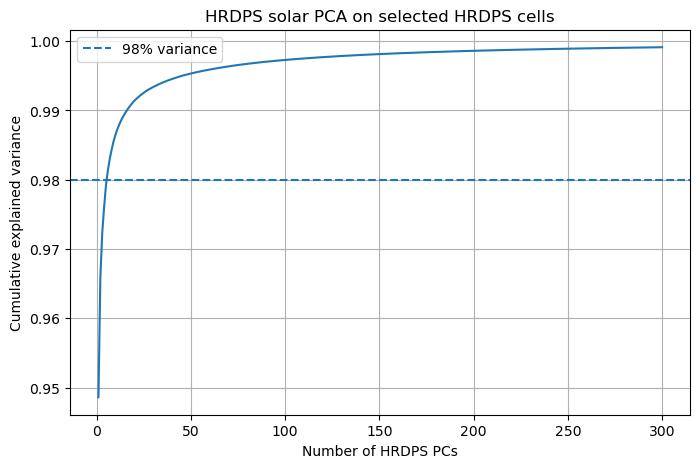

Number of HRDPS PCs needed for 98% variance: 6


In [26]:
hrdps_variance_threshold = 0.98

max_hrdps_pcs_for_search = min(300,X_hrdps_train.shape[0] - 1,X_hrdps_train.shape[1])
pca_hrdps = PCA(n_components=max_hrdps_pcs_for_search,svd_solver="randomized",random_state=0)
hrdps_train_scores_all = pca_hrdps.fit_transform(X_hrdps_train)
hrdps_cumulative_variance = np.cumsum(pca_hrdps.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, len(hrdps_cumulative_variance) + 1),hrdps_cumulative_variance)
plt.axhline(hrdps_variance_threshold, linestyle="--", label="98% variance")
plt.xlabel("Number of HRDPS PCs")
plt.ylabel("Cumulative explained variance")
plt.title("HRDPS solar PCA on selected HRDPS cells")
plt.legend()
plt.grid(True)
plt.show()
n_hrdps_pcs = np.argmax(hrdps_cumulative_variance >= hrdps_variance_threshold) + 1
print(f"Number of HRDPS PCs needed for 98% variance: {n_hrdps_pcs}")

In [27]:
hrdps_train_scores = hrdps_train_scores_all[:, :n_hrdps_pcs]
hrdps_val_scores = pca_hrdps.transform(X_hrdps_val)[:, :n_hrdps_pcs]
hrdps_test_scores = pca_hrdps.transform(X_hrdps_test)[:, :n_hrdps_pcs]
print("HRDPS train scores:", hrdps_train_scores.shape)
print("HRDPS val scores:  ", hrdps_val_scores.shape)
print("HRDPS test scores: ", hrdps_test_scores.shape)

HRDPS train scores: (8760, 6)
HRDPS val scores:   (2904, 6)
HRDPS test scores:  (2912, 6)


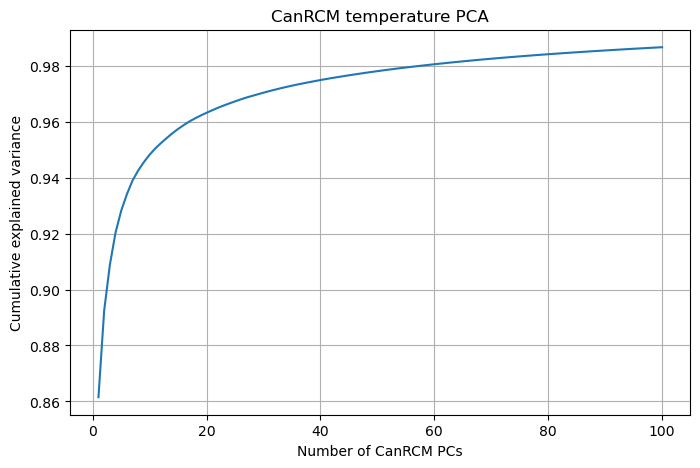

In [28]:
max_canrcm_pcs_for_search = min(100,X_canrcm_train.shape[0] - 1,X_canrcm_train.shape[1])
pca_canrcm = PCA(n_components=max_canrcm_pcs_for_search,svd_solver="randomized",random_state=0)
canrcm_train_scores_all = pca_canrcm.fit_transform(X_canrcm_train)
canrcm_val_scores_all = pca_canrcm.transform(X_canrcm_val)
canrcm_test_scores_all = pca_canrcm.transform(X_canrcm_test)
canrcm_cumulative_variance = np.cumsum(pca_canrcm.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, len(canrcm_cumulative_variance) + 1),canrcm_cumulative_variance)
plt.xlabel("Number of CanRCM PCs")
plt.ylabel("Cumulative explained variance")
plt.title("CanRCM temperature PCA")
plt.grid(True)
plt.show()

In [29]:
canrcm_pc_candidates = range(1, max_canrcm_pcs_for_search + 1)

val_r2_scores = []

for n_canrcm_pcs in canrcm_pc_candidates:
    X_train_pc = canrcm_train_scores_all[:, :n_canrcm_pcs]
    X_val_pc = canrcm_val_scores_all[:, :n_canrcm_pcs]
    model = LinearRegression()
    model.fit(X_train_pc, hrdps_train_scores)
    hrdps_val_scores_pred = model.predict(X_val_pc)
    val_r2 = r2_score(hrdps_val_scores,hrdps_val_scores_pred,multioutput="variance_weighted")
    val_r2_scores.append(val_r2)

val_r2_scores = np.array(val_r2_scores)

best_index = np.argmax(val_r2_scores)
n_canrcm_pcs = list(canrcm_pc_candidates)[best_index]

print("Best number of CanRCM PCs based on validation R²:")
print(n_canrcm_pcs)
print("Best validation R²:")
print(val_r2_scores[best_index])

Best number of CanRCM PCs based on validation R²:
33
Best validation R²:
0.8457147479057312


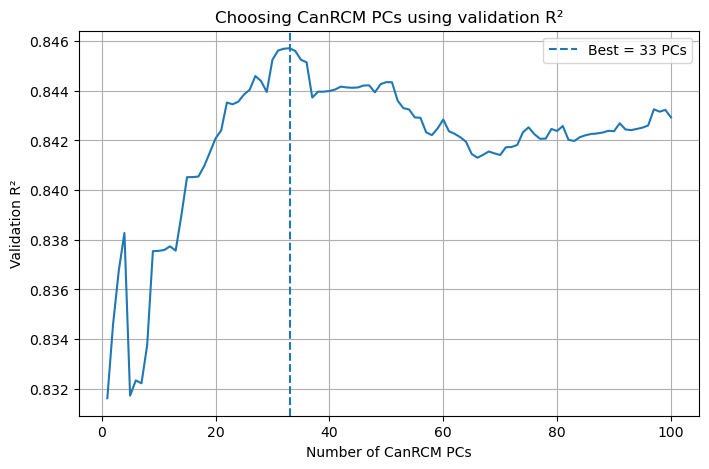

In [30]:
plt.figure(figsize=(8, 5))
plt.plot(list(canrcm_pc_candidates), val_r2_scores)
plt.axvline(n_canrcm_pcs, linestyle="--", label=f"Best = {n_canrcm_pcs} PCs")
plt.xlabel("Number of CanRCM PCs")
plt.ylabel("Validation R²")
plt.title("Choosing CanRCM PCs using validation R²")
plt.legend()
plt.grid(True)
plt.show()

In [31]:
X_train_pc_final = canrcm_train_scores_all[:, :n_canrcm_pcs]
X_val_pc_final = canrcm_val_scores_all[:, :n_canrcm_pcs]
X_test_pc_final = canrcm_test_scores_all[:, :n_canrcm_pcs]

lr_model = LinearRegression()
lr_model.fit(X_train_pc_final, hrdps_train_scores)

hrdps_train_scores_pred = lr_model.predict(X_train_pc_final)
hrdps_val_scores_pred = lr_model.predict(X_val_pc_final)
hrdps_test_scores_pred = lr_model.predict(X_test_pc_final)

print("Predicted HRDPS train scores:", hrdps_train_scores_pred.shape)
print("Predicted HRDPS val scores:  ", hrdps_val_scores_pred.shape)
print("Predicted HRDPS test scores: ", hrdps_test_scores_pred.shape)

Predicted HRDPS train scores: (8760, 6)
Predicted HRDPS val scores:   (2904, 6)
Predicted HRDPS test scores:  (2912, 6)


In [32]:
def inverse_from_selected_hrdps_pcs(scores, pca, n_pcs):
    reconstructed = np.dot(scores, pca.components_[:n_pcs, :])
    reconstructed = reconstructed + pca.mean_
    return reconstructed

In [33]:
X_hrdps_train_pred = inverse_from_selected_hrdps_pcs(hrdps_train_scores_pred,pca_hrdps,n_hrdps_pcs)
X_hrdps_val_pred = inverse_from_selected_hrdps_pcs(hrdps_val_scores_pred,pca_hrdps,n_hrdps_pcs)
X_hrdps_test_pred = inverse_from_selected_hrdps_pcs(hrdps_test_scores_pred,pca_hrdps,n_hrdps_pcs)
print("Predicted HRDPS train matrix:", X_hrdps_train_pred.shape)
print("Predicted HRDPS val matrix:  ", X_hrdps_val_pred.shape)
print("Predicted HRDPS test matrix: ", X_hrdps_test_pred.shape)

Predicted HRDPS train matrix: (8760, 4731)
Predicted HRDPS val matrix:   (2904, 4731)
Predicted HRDPS test matrix:  (2912, 4731)


In [34]:
def calculate_metrics(y_true, y_pred, label):
    rmse = np.sqrt(mean_squared_error(y_true.ravel(), y_pred.ravel()))
    mae = mean_absolute_error(y_true.ravel(), y_pred.ravel())
    bias = np.mean(y_pred - y_true)
    r2 = r2_score(y_true,y_pred,multioutput="variance_weighted")

    print(f"{label} metrics")
    print("RMSE:", rmse)
    print("MAE: ", mae)
    print("Bias:", bias)
    print("R^2:  ", r2)
    print()

    return {
        "RMSE": rmse,
        "MAE": mae,
        "Bias": bias,
        "R2": r2
    }

In [35]:
train_metrics = calculate_metrics(X_hrdps_train,X_hrdps_train_pred,"Train")
val_metrics = calculate_metrics(X_hrdps_val,X_hrdps_val_pred,"Validation")
test_metrics = calculate_metrics(X_hrdps_test,X_hrdps_test_pred,"Test")

Train metrics
RMSE: 80.1325683828055
MAE:  45.3109016418457
Bias: -0.00036632954
R^2:   0.8877472877502441

Validation metrics
RMSE: 96.92998439595459
MAE:  51.1969108581543
Bias: -1.3205197
R^2:   0.8268513083457947

Test metrics
RMSE: 84.85065004170563
MAE:  45.09128189086914
Bias: 6.0490265
R^2:   0.8593353629112244



In [36]:
def hrdps_vector_to_full_flat(vector, mask_HRDPS_flat_valid):
    full_hrdps = np.full(mask_HRDPS_flat_valid.shape,np.nan,dtype=np.float32)
    full_hrdps[mask_HRDPS_flat_valid] = vector.astype(np.float32)
    return full_hrdps

In [37]:
def interpolate_hrdps_field_to_ssc_water(hrdps_flat_field,ds_weights,water_mask): 
    water_flat = water_mask.reshape(-1)
    water_indices = np.where(water_flat)[0]

    n_water = len(water_indices)

    ssc_water_values = np.zeros(n_water, dtype=np.float32)
    weight_sum = np.zeros(n_water, dtype=np.float32)

    for n in range(1, 5):
        src_raw = (
            ds_weights[f"src{n:02d}"]
            .values
            .reshape(-1)[water_indices]
            .astype(np.int64)
        )

        weights = (
            ds_weights[f"wgt{n:02d}"]
            .values
            .reshape(-1)[water_indices]
            .astype(np.float32)
        )

        valid_source = src_raw > 0
        source_indices = np.where(valid_source, src_raw - 1, 0)

        source_values = hrdps_flat_field[source_indices]

        valid = (
            valid_source
            & np.isfinite(source_values)
            & np.isfinite(weights)
            & (weights > 0)
        )

        ssc_water_values += np.where(
            valid,
            source_values * weights,
            0.0
        )

        weight_sum += np.where(
            valid,
            weights,
            0.0
        )

    ssc_water_values = np.divide(
        ssc_water_values,
        weight_sum,
        out=np.full(n_water, np.nan, dtype=np.float32),
        where=weight_sum > 0
    )

    # Create the full flattened SSC grid
    ssc_full = np.full(
        water_mask.size,
        np.nan,
        dtype=np.float32
    )

    # Put values only at SSC water-cell locations
    ssc_full[water_indices] = ssc_water_values

    # Return a 2D SSC map
    return ssc_full.reshape(water_mask.shape)

In [38]:
def plot_ssc_actual_pred_error(
    time_index,
    X_actual,
    X_pred,
    mask_HRDPS_flat_valid,
    ds_weights,
    water_mask,
    ds_mask,
    times=None
):
    # Reduced HRDPS vectors for the selected timestamp
    actual_hrdps_vector = X_actual[time_index]
    predicted_hrdps_vector = X_pred[time_index]

    # Restore reduced vectors onto full flattened HRDPS grid
    actual_hrdps_full = hrdps_vector_to_full_flat(
        actual_hrdps_vector,
        mask_HRDPS_flat_valid
    )

    predicted_hrdps_full = hrdps_vector_to_full_flat(
        predicted_hrdps_vector,
        mask_HRDPS_flat_valid
    )

    # Interpolate full HRDPS fields onto full 2D SSC grid
    actual_ssc_map = interpolate_hrdps_field_to_ssc_water(
        actual_hrdps_full,
        ds_weights,
        water_mask
    )

    predicted_ssc_map = interpolate_hrdps_field_to_ssc_water(
        predicted_hrdps_full,
        ds_weights,
        water_mask
    )

    error_ssc_map = predicted_ssc_map - actual_ssc_map

    print("SSC water-mask shape:", water_mask.shape)
    print("Actual SSC map shape:", actual_ssc_map.shape)
    print("Predicted SSC map shape:", predicted_ssc_map.shape)

    assert actual_ssc_map.shape == water_mask.shape
    assert predicted_ssc_map.shape == water_mask.shape
    assert error_ssc_map.shape == water_mask.shape

    vmin = np.nanmin(
        np.stack([actual_ssc_map, predicted_ssc_map])
    )

    vmax = np.nanmax(
        np.stack([actual_ssc_map, predicted_ssc_map])
    )

    err_abs = np.nanmax(np.abs(error_ssc_map))

    if times is not None:
        title_suffix = str(pd.to_datetime(times[time_index]))
    else:
        title_suffix = f"time index {time_index}"

    lon_ssc = ds_mask["nav_lon"].values
    lat_ssc = ds_mask["nav_lat"].values

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    p0 = axes[0].pcolormesh(
    actual_ssc_map,
    shading="auto",
    vmin=vmin,
    vmax=vmax,
    cmap="viridis"
    )
    axes[0].set_title(f"Actual on SSC Grid\n{title_suffix}")
    plt.colorbar(p0, ax=axes[0])

    p1 = axes[1].pcolormesh(
    predicted_ssc_map,
    shading="auto",
    vmin=vmin,
    vmax=vmax,
    cmap="viridis"
    )
    axes[1].set_title(f"Predicted on SSC Grid\n{title_suffix}")
    plt.colorbar(p1, ax=axes[1])

    p2 = axes[2].pcolormesh(
    error_ssc_map,
    shading="auto",
    vmin=-err_abs,
    vmax=err_abs,
    cmap="RdBu_r"
    )
    axes[2].set_title(
        f"Error: Predicted − Actual\n{title_suffix}"
    )
    plt.colorbar(p2, ax=axes[2])

    for ax in axes:
        ax.set_xlabel("x")
        ax.set_ylabel("y")

    plt.tight_layout()
    plt.show()

SSC water-mask shape: (898, 398)
Actual SSC map shape: (898, 398)
Predicted SSC map shape: (898, 398)


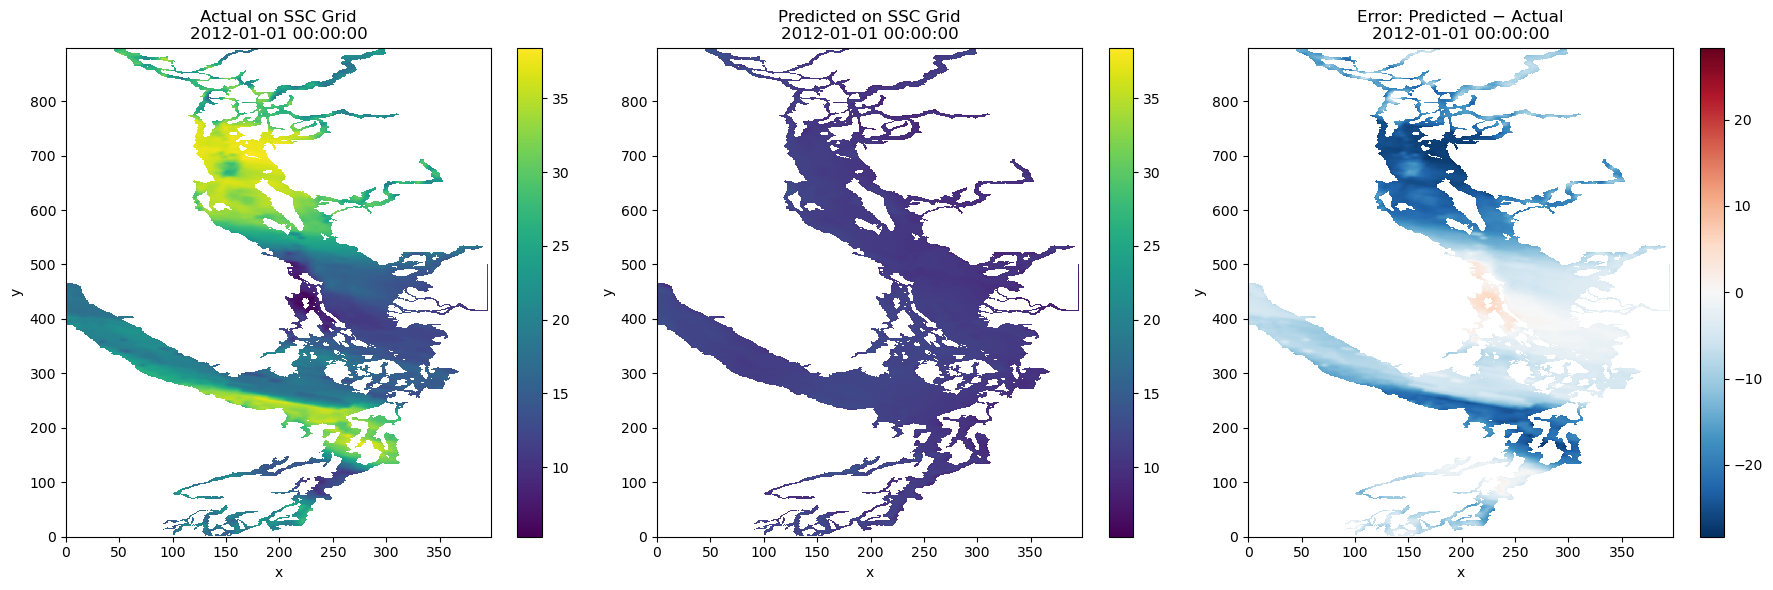

SSC water-mask shape: (898, 398)
Actual SSC map shape: (898, 398)
Predicted SSC map shape: (898, 398)


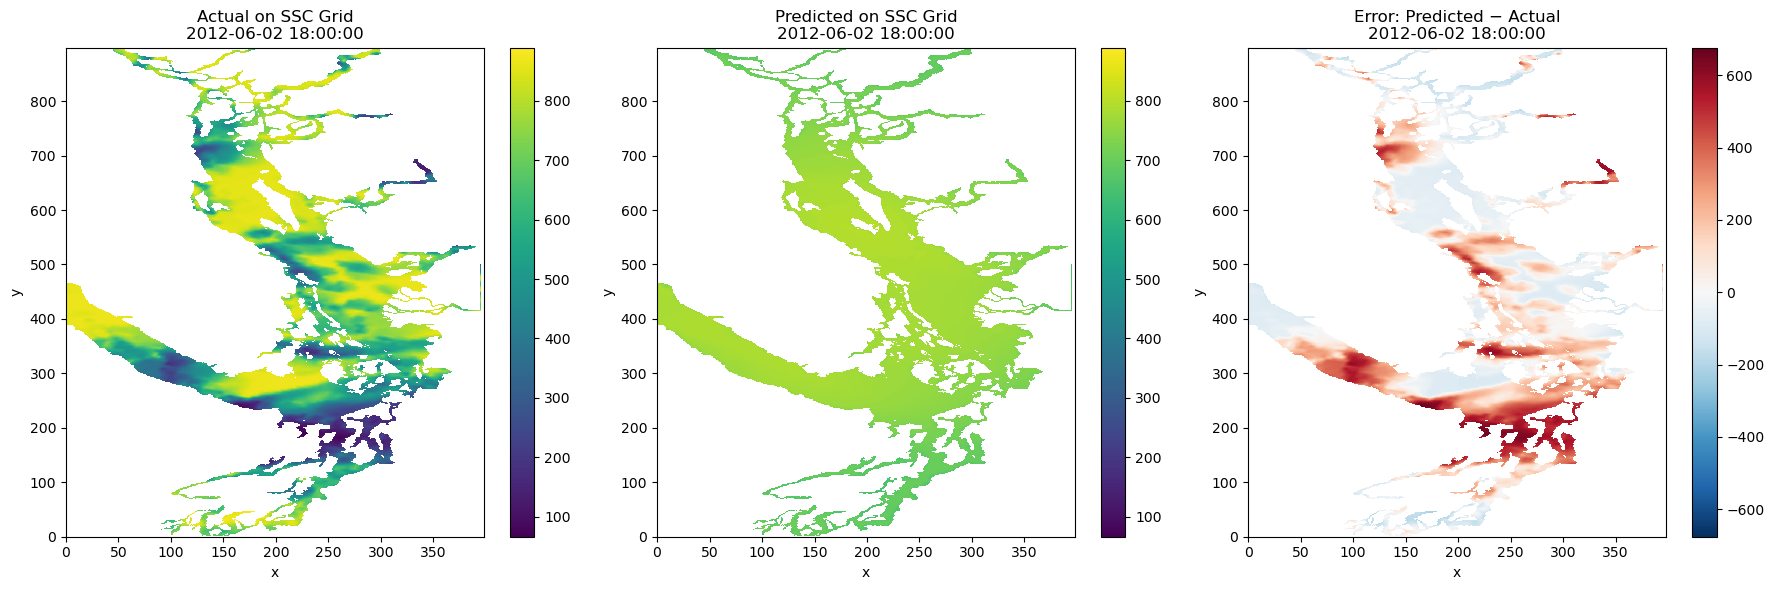

In [39]:
test_times = pd.to_datetime(
    ds_hrdps_test["time_counter"].values
)

plot_ssc_actual_pred_error(
    time_index=0,
    X_actual=X_hrdps_test,
    X_pred=X_hrdps_test_pred,
    mask_HRDPS_flat_valid=mask_HRDPS_flat_valid,
    ds_weights=ds_weights,
    water_mask=water_mask,
    ds_mask=ds_mask,
    times=test_times
)

plot_ssc_actual_pred_error(
    time_index=1222,
    X_actual=X_hrdps_test,
    X_pred=X_hrdps_test_pred,
    mask_HRDPS_flat_valid=mask_HRDPS_flat_valid,
    ds_weights=ds_weights,
    water_mask=water_mask,
    ds_mask=ds_mask,
    times=test_times
)

In [40]:
def calculate_ssc_spatial_mean_timeseries(X_hrdps,mask_HRDPS_flat_valid,ds_weights,water_mask,chunk_size=16):

    water_indices = np.where(water_mask.reshape(-1))[0]
    n_water = len(water_indices)

    full_to_reduced = np.full(mask_HRDPS_flat_valid.size,-1,dtype=np.int64)

    full_to_reduced[mask_HRDPS_flat_valid] = np.arange(mask_HRDPS_flat_valid.sum())

    source_information = []
    total_weight = np.zeros(n_water, dtype=np.float32)

    for n in range(1, 5):
        src_raw = (
            ds_weights[f"src{n:02d}"]
            .values
            .reshape(-1)[water_indices]
            .astype(np.int64)
        )

        weights = (
            ds_weights[f"wgt{n:02d}"]
            .values
            .reshape(-1)[water_indices]
            .astype(np.float32)
        )

        full_source_index = src_raw - 1

        source_in_bounds = (
            (src_raw > 0)
            & (full_source_index >= 0)
            & (full_source_index < mask_HRDPS_flat_valid.size)
        )

        reduced_source_index = np.full(
            n_water,
            -1,
            dtype=np.int64
        )

        reduced_source_index[source_in_bounds] = (
            full_to_reduced[full_source_index[source_in_bounds]]
        )

        valid = (
            source_in_bounds
            & (reduced_source_index >= 0)
            & np.isfinite(weights)
            & (weights > 0)
        )

        # Safe index for array selection; invalid cells get zero weight
        safe_source_index = np.where(
            valid,
            reduced_source_index,
            0
        )

        effective_weight = np.where(
            valid,
            weights,
            0.0
        ).astype(np.float32)

        source_information.append(
            (safe_source_index, effective_weight)
        )

        total_weight += effective_weight

    # Water cells for which at least one valid HRDPS source exists
    valid_water = total_weight > 0
    n_valid_water = valid_water.sum()

    print("SalishSeaCast water cells:", n_water)
    print("Water cells with valid interpolation:", n_valid_water)

    # Normalize the interpolation weights for each water cell
    normalized_sources = []

    for source_index, source_weight in source_information:

        normalized_weight = (
            source_weight[valid_water]
            / total_weight[valid_water]
        )

        normalized_sources.append(
            (
                source_index[valid_water],
                normalized_weight
            )
        )

    n_time = X_hrdps.shape[0]
    spatial_mean = np.empty(n_time, dtype=np.float64)

    # Process timestamps in chunks to control memory use
    for start in range(0, n_time, chunk_size):

        end = min(start + chunk_size, n_time)

        X_chunk = X_hrdps[start:end]
        chunk_mean = np.zeros(end - start, dtype=np.float64)

        for source_index, normalized_weight in normalized_sources:

            contribution = (
                X_chunk[:, source_index]
                * normalized_weight[None, :]
            )

            chunk_mean += np.sum(contribution, axis=1)

        spatial_mean[start:end] = chunk_mean / n_valid_water

    return spatial_mean

In [41]:
test_times = pd.to_datetime(ds_hrdps_test["time_counter"].values)

actual_mean_solar = calculate_ssc_spatial_mean_timeseries(
    X_hrdps=X_hrdps_test,
    mask_HRDPS_flat_valid=mask_HRDPS_flat_valid,
    ds_weights=ds_weights,
    water_mask=water_mask
)

predicted_mean_solar = calculate_ssc_spatial_mean_timeseries(
    X_hrdps=X_hrdps_test_pred,
    mask_HRDPS_flat_valid=mask_HRDPS_flat_valid,
    ds_weights=ds_weights,
    water_mask=water_mask
)

solar_timeseries = pd.DataFrame(
    {
        "actual": actual_mean_solar,
        "predicted": predicted_mean_solar
    },
    index=test_times
)

solar_timeseries.index.name = "Date"

print(solar_timeseries.head())
print("Number of 3-hourly timestamps:", len(solar_timeseries))

SalishSeaCast water cells: 81383
Water cells with valid interpolation: 81383
SalishSeaCast water cells: 81383
Water cells with valid interpolation: 81383
                        actual  predicted
Date                                     
2012-01-01 00:00:00  22.081487   11.01720
2012-01-01 03:00:00   0.000000    5.38639
2012-01-01 06:00:00   0.000000    5.38639
2012-01-01 09:00:00   0.000000    5.38639
2012-01-01 12:00:00   0.000000    5.38639
Number of 3-hourly timestamps: 2912


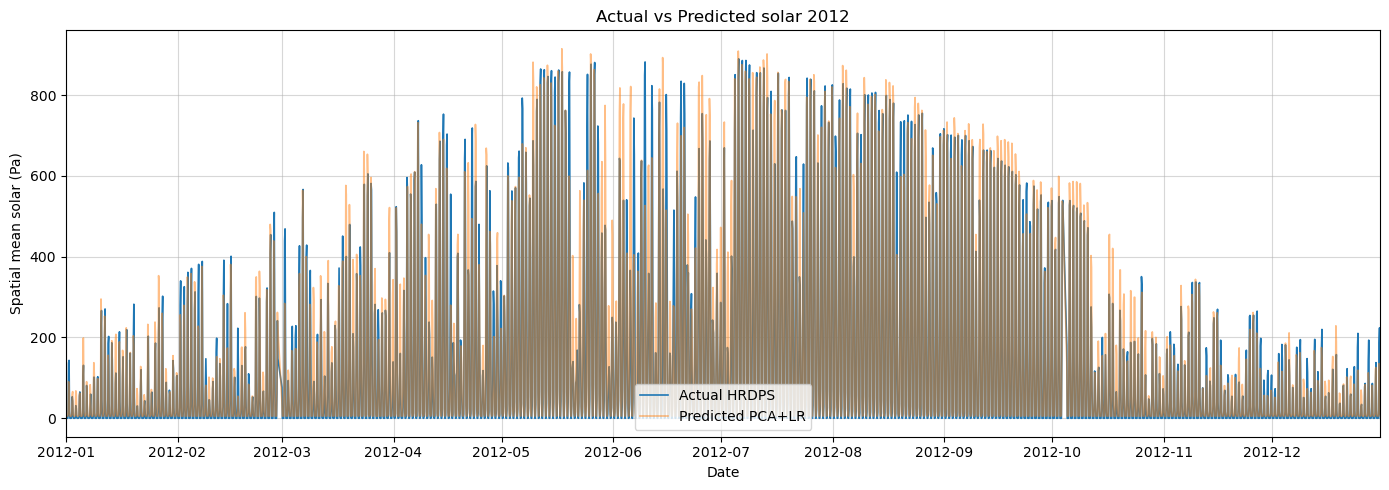

In [42]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(solar_timeseries.index,solar_timeseries["actual"],label="Actual HRDPS",linewidth=1.2)
ax.plot(solar_timeseries.index,solar_timeseries["predicted"],label="Predicted PCA+LR",linewidth=1.2,alpha=0.5)
ax.set_xlim(pd.Timestamp("2012-01-01"),pd.Timestamp("2012-12-31"))
ax.set_xlabel("Date")
ax.set_ylabel("Spatial mean solar (Pa)")
ax.set_title("Actual vs Predicted solar 2012")
ax.legend(loc="lower center",frameon=True)
ax.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

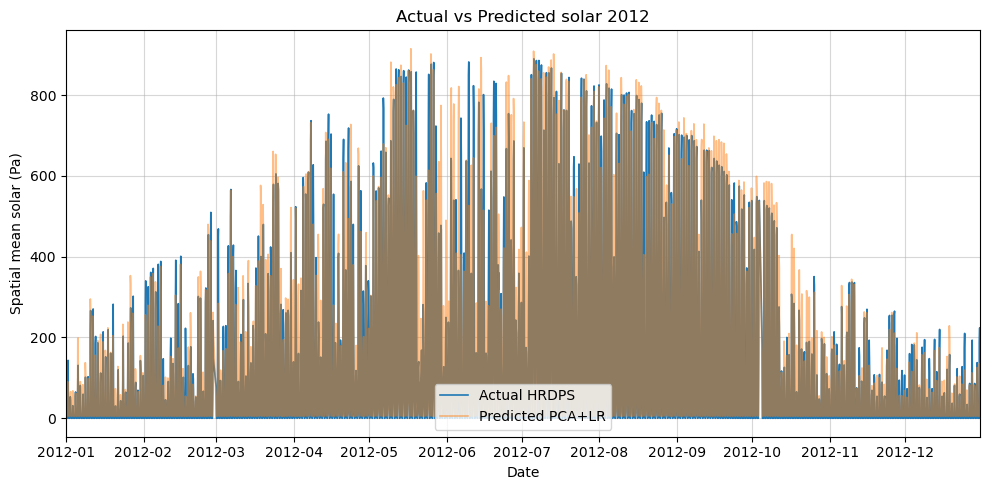

In [43]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(solar_timeseries.index,solar_timeseries["actual"],label="Actual HRDPS",linewidth=1.2)
ax.plot(solar_timeseries.index,solar_timeseries["predicted"],label="Predicted PCA+LR",linewidth=1.2,alpha=0.5)
ax.set_xlim(pd.Timestamp("2012-01-01"),pd.Timestamp("2012-12-31"))
ax.set_xlabel("Date")
ax.set_ylabel("Spatial mean solar (Pa)")
ax.set_title("Actual vs Predicted solar 2012")
ax.legend(loc="lower center",frameon=True)
ax.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

In [44]:
stations = {
    "Halibut Bank (HB)": (142, 139),
    "Sentry Shoal (SS)": (174, 107),
    "Sand Heads (SH)": (129, 149)
}

In [45]:
def get_reduced_hrdps_column(y, x, mask_HRDPS_2d_valid):
    ny, nx = mask_HRDPS_2d_valid.shape
    full_flat_index = np.ravel_multi_index((y, x),mask_HRDPS_2d_valid.shape)
    valid_flat_indices = np.flatnonzero(mask_HRDPS_2d_valid.reshape(-1))
    reduced_column = np.searchsorted(valid_flat_indices,full_flat_index)
    return reduced_column

In [49]:
station_series = {}
station_rmse = {}

for station_name, (y, x) in stations.items():
    column = get_reduced_hrdps_column(y=y,x=x,mask_HRDPS_2d_valid=mask_HRDPS_2d_valid)
    actual = X_hrdps_test[:, column]
    predicted = X_hrdps_test_pred[:, column]
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    station_series[station_name] = {"actual": actual,"predicted": predicted,"column": column}
    station_rmse[station_name] = rmse
    print(
        f"{station_name}: grid coordinate ({y}, {x}), "
        f"reduced column {column}, RMSE = {rmse:.3f}"
    )

Halibut Bank (HB): grid coordinate (142, 139), reduced column 2958, RMSE = 80.765
Sentry Shoal (SS): grid coordinate (174, 107), reduced column 3907, RMSE = 83.262
Sand Heads (SH): grid coordinate (129, 149), reduced column 2564, RMSE = 83.627


In [50]:
average_station_rmse = np.mean(list(station_rmse.values()))
print("Average RMSE across the three stations: ",average_station_rmse)

Average RMSE across the three stations:  82.55154435655226


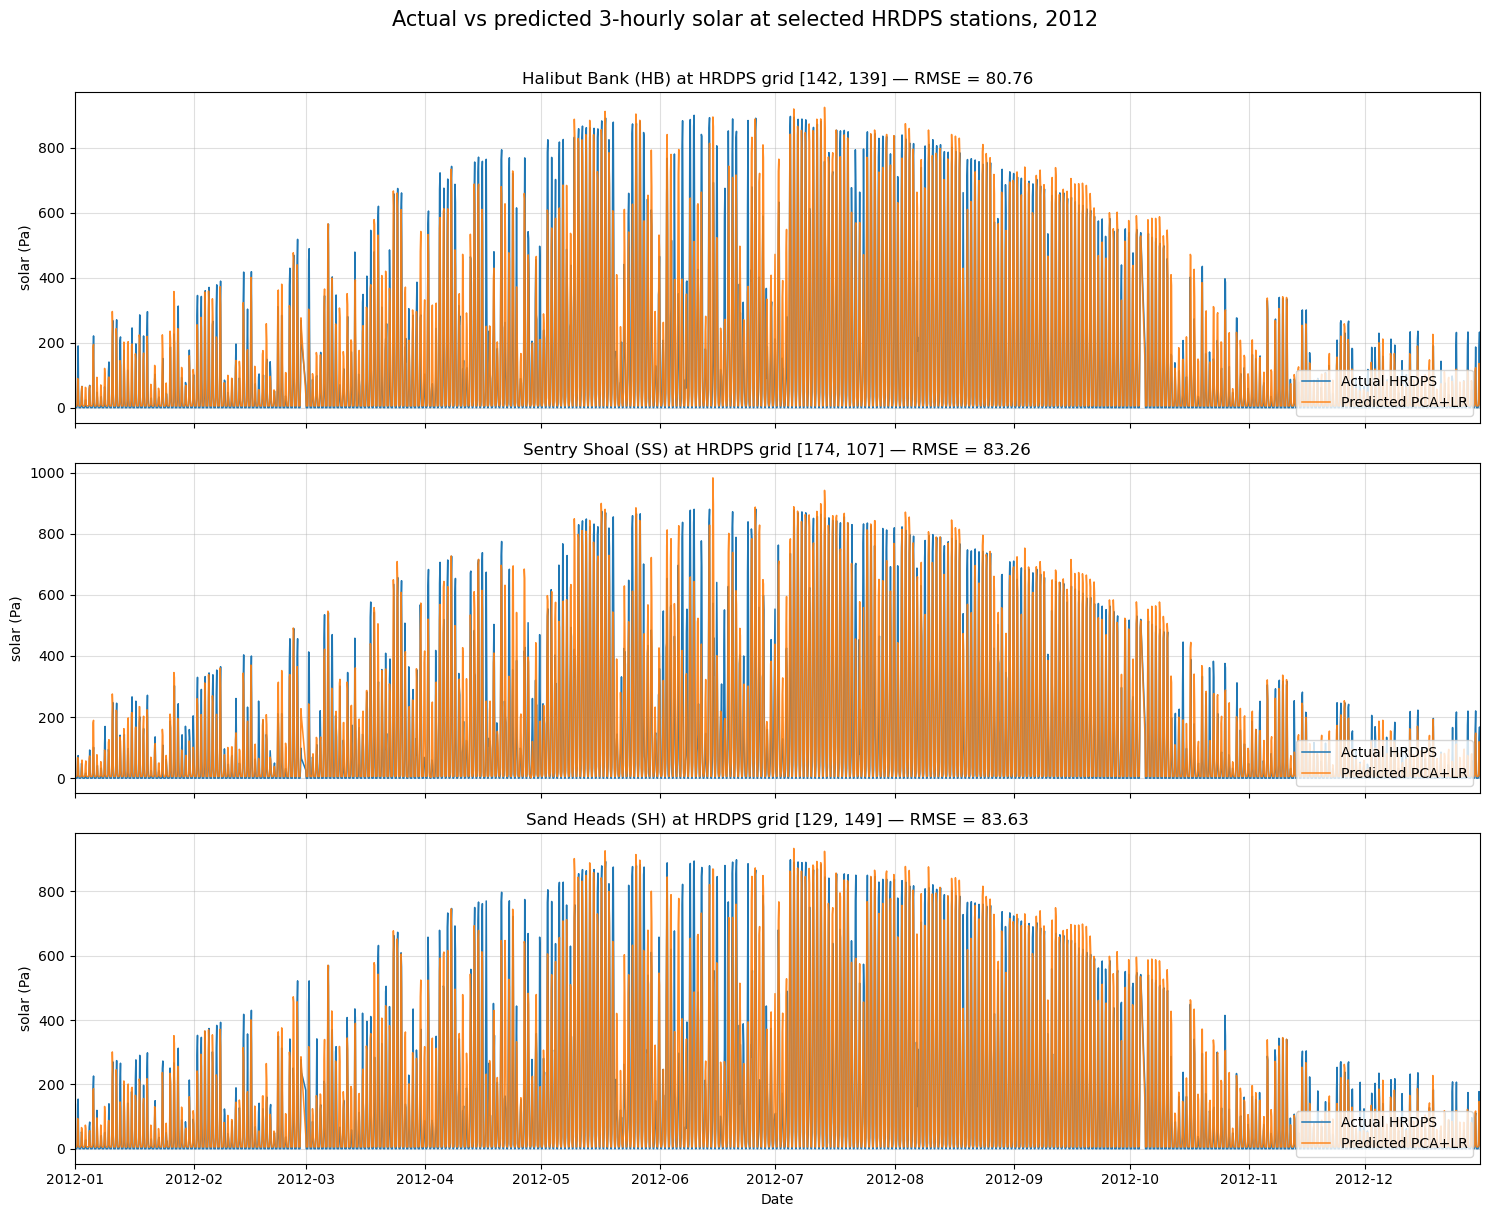

In [51]:
fig, axes = plt.subplots(nrows=3,ncols=1,figsize=(15, 12),sharex=True)
for ax, (station_name, values) in zip(axes,station_series.items()):
    actual = values["actual"]
    predicted = values["predicted"]
    rmse = station_rmse[station_name]

    ax.plot(test_times,actual,label="Actual HRDPS",linewidth=1.1)
    ax.plot(test_times,predicted,label="Predicted PCA+LR",linewidth=1.1,alpha=0.9)

    y, x = stations[station_name]

    ax.set_title(
        f"{station_name} at HRDPS grid [{y}, {x}] "
        f"— RMSE = {rmse:.2f}"
    )

    ax.set_ylabel("solar (Pa)")
    ax.grid(True, alpha=0.4)
    ax.legend(loc="lower right")


axes[-1].set_xlabel("Date")

fig.suptitle("Actual vs predicted 3-hourly solar at selected HRDPS stations, 2012",fontsize=15,y=1.01)
for ax in axes:ax.set_xlim(pd.Timestamp("2012-01-01"),pd.Timestamp("2012-12-31"))
plt.tight_layout()
plt.show()

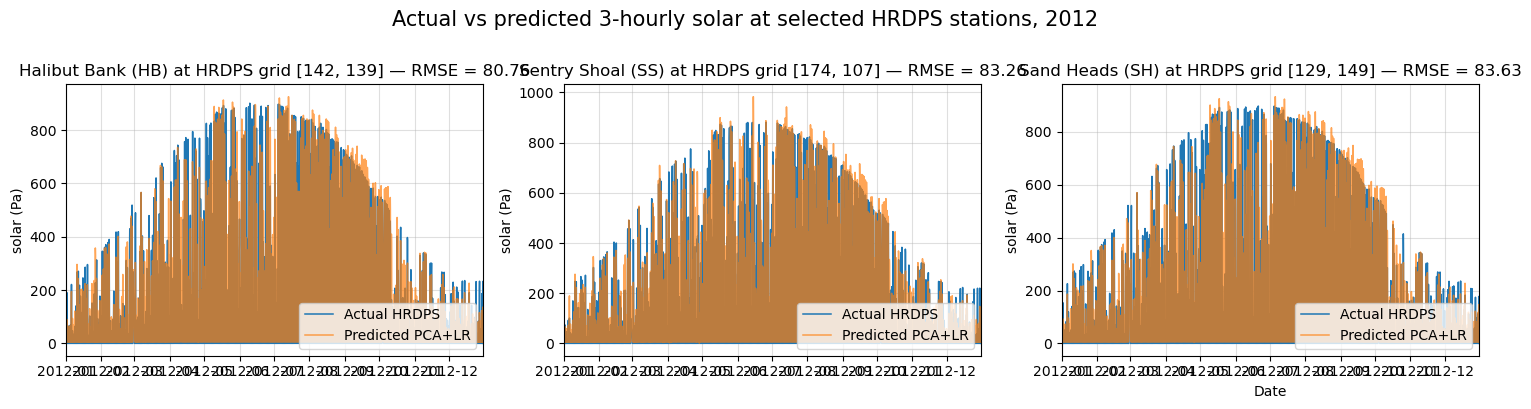

In [54]:
fig, axes = plt.subplots(nrows=1,ncols=3,figsize=(15, 4),sharex=True)
for ax, (station_name, values) in zip(axes,station_series.items()):
    actual = values["actual"]
    predicted = values["predicted"]
    rmse = station_rmse[station_name]

    ax.plot(test_times,actual,label="Actual HRDPS",linewidth=1.1)
    ax.plot(test_times,predicted,label="Predicted PCA+LR",linewidth=1.1,alpha=0.7)

    y, x = stations[station_name]

    ax.set_title(
        f"{station_name} at HRDPS grid [{y}, {x}] "
        f"— RMSE = {rmse:.2f}"
    )

    ax.set_ylabel("solar (Pa)")
    ax.grid(True, alpha=0.4)
    ax.legend(loc="lower right")


axes[-1].set_xlabel("Date")

fig.suptitle("Actual vs predicted 3-hourly solar at selected HRDPS stations, 2012",fontsize=15,y=1.01)
for ax in axes:ax.set_xlim(pd.Timestamp("2012-01-01"),pd.Timestamp("2012-12-31"))
plt.tight_layout()
plt.show()